<a href="https://colab.research.google.com/github/saumyasingh993671/python-first-file/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import files

# 1. Prompt you to upload your kaggle.json file
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

    # 2. Move the uploaded file to the required directory
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/

    # 3. Change file permissions to protect your API credentials
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API successfully configured!")
else:
    print("Kaggle API already configured.")

Kaggle API already configured.


In [ ]:
# 1. Download the dataset zip file using the Kaggle API command
# Format: !kaggle datasets download -d [dataset-owner]/[dataset-name]
!kaggle datasets download -d carrie1/ecommerce-data

# 2. Unzip the downloaded archive
!unzip ecommerce-data.zip

# 3. Load the unzipped CSV file into a Pandas DataFrame
import pandas as pd
df = pd.read_csv('data.csv', encoding="ISO-8859-1")

# Preview the downloaded Kaggle data
df.head()

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
ecommerce-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ecommerce-data.zip
replace data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Filter out negative quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create Total Price column
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalSum     397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB
None


In [ ]:
# 3. CALCULATE RFM METRICS
# ==========================================
# Establish target date (1 day after the latest transaction in dataset)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group fields by CustomerID
rfm = df.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency (Unique orders)
    'TotalSum': 'sum'                                        # Monetary Value
})

# Rename columns to match standard analytical frameworks
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

In [ ]:
4. #SCORE SEGMENTS (QUARTILES)
# ==========================================
# Split into 4 metric bins
r_labels = range(4, 0, -1) # Lower recency value is a better customer
f_labels = range(1, 5)     # Higher unique order frequency is better
m_labels = range(1, 5)     # Higher financial spend is better

r_groups = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
# Use 'first' method to handle heavy ties in uniform purchase frequencies safely
f_groups = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
m_groups = pd.qcut(rfm['MonetaryValue'], q=4, labels=m_labels)

rfm = rfm.assign(R=r_groups.values, F=f_groups.values, M=m_groups.values)



In [ ]:
#  5. CREATE HUMAN-READABLE LABELS
# ==========================================
def segment_me(row):
    if row['R'] == 4 and row['F'] == 4:
        return 'Champions'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Loyal Customers'
    elif row['R'] >= 3 and row['M'] >= 3:
        return 'Potential Loyalists'
    elif row['R'] == 1:
        return 'At Risk / Lost'
    else:
        return 'Standard / Occasional'

rfm['General_Segment'] = rfm.apply(segment_me, axis=1)


/tmp/ipykernel_5025/325724141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='General_Segment', palette='viridis', order=order_list)


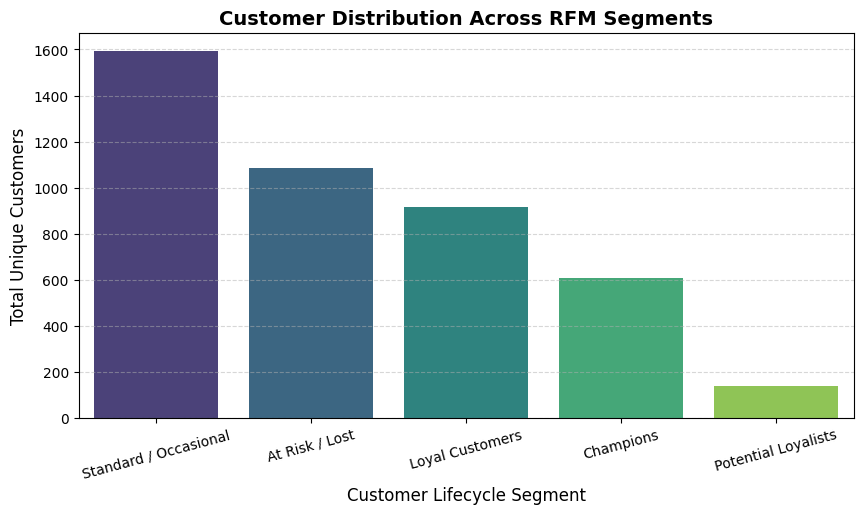


Processing complete! Look below to use your interactive dashboard dashboard form.


In [ ]:
# 6. VISUALIZING THE SEGMENTS
# ==========================================
plt.figure(figsize=(10, 5))
order_list = rfm['General_Segment'].value_counts().index
sns.countplot(data=rfm, x='General_Segment', palette='viridis', order=order_list)
plt.title('Customer Distribution Across RFM Segments', fontsize=14, fontweight='bold')
plt.xlabel('Customer Lifecycle Segment', fontsize=12)
plt.ylabel('Total Unique Customers', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("\nProcessing complete! Look below to use your interactive dashboard dashboard form.")